Importing the required packages<br>
Loading envrionment variables from .env file

In [1]:


from typing import TypedDict

from IPython.display import Image, display
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, END
from langchain_core.messages import HumanMessage

load_dotenv()

True

In [2]:
llm = ChatOpenAI(model="gpt-5.1", temperature=0.05)

In [3]:
# -----------------------
# 1. Define the State
# -----------------------
class AgentState(TypedDict):
    messages: []
    task: str
    output: str                                   # The original user task
    critique: str                               # Critique from reflector
    revision_count: int                         # How many reflection rounds
    max_revisions: int                          # Stop condition

Please feel free to modify the prompts as per the use case

In [4]:
def writer_node(state: AgentState):
    """
    First generates the content
    If there's feedback updates the content based on the
        - Task
        - previous output
        - Feedback
    :param state:
    :return:
    """
    try:
        prompt = f"""
        You are the best software engineer in the development. You can solve anything at ease. You are expert in all the programming languages. You have helped many companies solve may complex problems! You helped many start-ups turn into billion dollars within a short span. You follow best for the output code SDE practices like Try, catch/except blocks, logger, DocStrings, naming standards, etc.
        Given the following task generate the code: {state['task']}

        Produce only the new code.
        """

        # updating the prompt if there's a feedback
        if state["revision_count"]>0:
            prompt = f"""
            You are the best software engineer in the development. You can solve anything at ease. You are expert in all the programming languages. You have helped many companies solve may complex problems! You helped many start-ups turn into billion dollars within a short span. Few top SDE reviewers across the world would review and give feedback. Use it as a constructive feedback and further enhance the task output.

            Previous Code: {state.get('output', 'None - this is the first draft')}
            Critique Feedback: {state.get('critique', 'None')}

            Given the following task generate the code: {state['task']}


            Produce only the new code.
            """

        # Invoking llm
        response = llm.invoke([HumanMessage(content=prompt)])
        # print(f"Successfully generated code: {response}")
        state["output"] = response.content
        state["messages"] = state["messages"] + [response]
        print("Successfully generated code")
    except Exception as ex:
        print(f"Error while generating code: {ex}")
        state["revision_count"] = 2
        # return {"critique": "", "messages": []}
    return state

In [5]:
def reflector_node(state: AgentState):
    """
    Based on the content from writer
    review the output and give the feedback
    :param state:
    :return:
    """
    try:
        # Please update the prompt as per your use case
        prompt = f"""
        You are a harsh but constructive critic for the code reviews. Your feedback helps to improve the product quality as well save time and resources
        Task: {state['task']}

        Current output code:
        {state['output']}

        Provide a bullet-point critique covering:
        - Issue wrt code
        - Do the code meet the coding standards
        - Try catch or except blocks as per the programming language
        - Docstring at Class, Method or function level
        - Variable naming conventions
        - Are there any issues like forever in while loop without break of end state.
        - Is the code shared optimal
        - Is the code structured and easy to understand
        -

        Be specific and actionable. Do NOT rewrite the draft.
        """

        # - Emotional appeal / persuasiveness
        # - Uniqueness / creativity
        # - Grammar and style
        response = llm.invoke([HumanMessage(content=prompt)])
        state["critique"] = response.content
        state["messages"] = state["messages"] + [response]
        state["revision_count"] += 1
        print("Successfully reviewed code")
        return state
    except Exception as ex:
        print(f"Error while generating code: {ex}")
        state["revision_count"] = 2
    return state

In [6]:
def should_continue(state: AgentState):
    if state["revision_count"] >= state["max_revisions"]:
        return "end"
    # if state["revision_count"]==3:
    #     return "end"
    return "continue"

In [7]:
# -----------------------
# 3. Build the Graph
# -----------------------
workflow = StateGraph(AgentState)

workflow.add_node("writer", writer_node)
workflow.add_node("reflector", reflector_node)
# workflow.add_edge("end", END)

workflow.set_entry_point("writer")



In [8]:
workflow.add_conditional_edges(
    "writer",
    should_continue,
    {
        "continue": "reflector",
        "end": END
    }
)

In [9]:
workflow.add_edge("reflector", "writer")

In [10]:
app = workflow.compile()


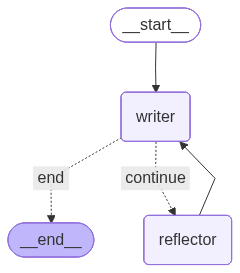

In [11]:
display(Image(app.get_graph().draw_mermaid_png()))

In [29]:
input = AgentState(task="""Write python function to check if the following patterns exists in the string with following pattern '2019-10-EF-25' extract and validate the pattern.
From the above pattern
2019: the year which is should be less than or equal the current year
10: it is month which should be in the range 0-12
EF: is the custom internal pattern
25: It is day of the month

If it's a valid pattern return the valid pattern else return empty string
""",
                   critique="",
                   revision_count=0,
                   max_revisions=1,
                   messages=[])

In [30]:
output_state = app.invoke(input)

Successfully generated code
Successfully reviewed code
Successfully generated code


In [ ]:
for message in output_state["messages"]:
    print(message.content,"\n\n")

If you give more precise prompt you can get better results

In [16]:
input_query = AgentState(task="""Write python class for connecting and querying LLM's with following methods
1. connect_openai: Connect to OpenAI with default model as gpt-4o-mini
2. connect_anthropic: Connect to Anthropic with default model as claude-sonnet-4-5-20250929
3. connect_grok: to grok with default model as grok-code-fast-1
4. connect_gemini: Connect to gemini with default model as Gemini 2.5 Pro
5. query_openai: Query OpenAI using input message
6. query_anthropic: query Anthropic using input message
7. query_grok: Query grok model using input message
8. query_gemini: Query gemini using input message
set the default temperature for the models as 0.05
""",
                   critique="",
                   revision_count=0,
                   max_revisions=1,
                   messages=[])

In [17]:
output_state_1 = app.invoke(input_query)

Successfully generated code
Successfully reviewed code
Successfully generated code


In [ ]:
for message in output_state_1["messages"]:
    print(message.content,"\n\n")

In [18]:
input_query_1 = AgentState(task="""Write python class for connecting and querying LLM's with following methods
1. connect_openai: Connect to OpenAI with default model as gpt-4o-mini
2. connect_anthropic: Connect to Anthropic with default model as claude-sonnet-4-5-20250929
3. connect_grok: to grok with default model as grok-code-fast-1
4. connect_gemini: Connect to gemini with default model as Gemini 2.5 Pro
5. query_openai: Query OpenAI using input message
6. query_anthropic: query Anthropic using input message
7. query_grok: Query grok model using input message
8. query_gemini: Query gemini using input message

Using  langchain's ChatOpenAI, ChatGoogleGenerativeAI ,ChatAnthropic, ChatXAI, etc to connect to model. As well use the appropriate llm's to query.
set the default temperature for the models as 0.05

""",
                   critique="",
                   revision_count=0,
                   max_revisions=1,
                   messages=[])

In [19]:
output_query_1 = app.invoke(input_query_1)

Successfully generated code
Successfully reviewed code
Successfully generated code


In [22]:
input_query_2 = AgentState(task="""Write python class for connecting and querying LLM's with following methods
1. connect_openai: Connect to OpenAI with default model as gpt-4o-mini
2. connect_anthropic: Connect to Anthropic with default model as claude-sonnet-4-5-20250929
3. connect_grok: to grok with default model as grok-code-fast-1
4. connect_gemini: Connect to gemini with default model as Gemini 2.5 Pro
5. query_openai: Query OpenAI using input message using the  connection variable from connection_openai
6. query_anthropic: query Anthropic using input message using the connection variable from connection_openai
7. query_grok: Query grok model using input message using the connection variable from connect_grok
8. query_gemini: Query gemini using input message connection variable from connect_gemini

Using  langchain's ChatOpenAI, ChatGoogleGenerativeAI ,ChatAnthropic, ChatXAI, etc to connect to model. As well use the appropriate llm's to query.
For all the llm's create a unique variable when connecting which can be reused while querying as well.
set the default temperature for the models as 0.05
load keys from .env using from dotenv import load_dotenv

share the key names in comments like OPENAI_API_KEY, etc which need to be updated in .env file
""",
                   critique="",
                   revision_count=0,
                   max_revisions=1,
                   messages=[])

In [23]:
output_query_2 = app.invoke(input_query_2)

Successfully generated code
Successfully reviewed code
Successfully generated code


In [24]:
for message in output_query_2["messages"]:
    print(message.content,"\n\n")

```python
"""
llm_client.py

Python class for connecting to and querying multiple LLM providers using LangChain.

Environment variables required in .env (example names):
- OPENAI_API_KEY=<your_openai_key>
- ANTHROPIC_API_KEY=<your_anthropic_key>
- XAI_API_KEY=<your_grok_xai_key>
- GOOGLE_API_KEY=<your_gemini_google_key>
"""

import logging
from typing import Optional

from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_xai import ChatXAI


# Load environment variables from .env
load_dotenv()

# Configure logger
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

# Optional: add a default console handler if none exist
if not logger.handlers:
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.INFO)
    formatter = logging.Formatter(
        "%(asctime)s - %(name)s - %(levelname)s - %(message)s"
    )
   